---
# NLI Analysis - FIGER
> Laura Komorek
---

This notebook analyzes the performance of the fine-tuned distilled-RoBERTa model on the FIGER test set.

We are focusing on:
- Error Analysis
- Robustness and Probing

---
## Imports

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import random
import torch
import spacy
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification

%matplotlib inline

---
## Load FIGER

In [2]:
with open("figer_test_predictions.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(df.columns)
df.head(2)

Index(['premise', 'hypothesis', 'gold_label', 'prediction'], dtype='object')


,premise,hypothesis,gold_label,prediction
0,"He breaks free , so Ana Lucia follows and find...",Harold Perrineau is a /common/topic.,ENTAILMENT,ENTAILMENT
1,"Deposed after a revolt by the nobles , in favo...",George VII of Imereti is a /people/deceased_pe...,ENTAILMENT,ENTAILMENT


---
## Label Distribution and Baselines

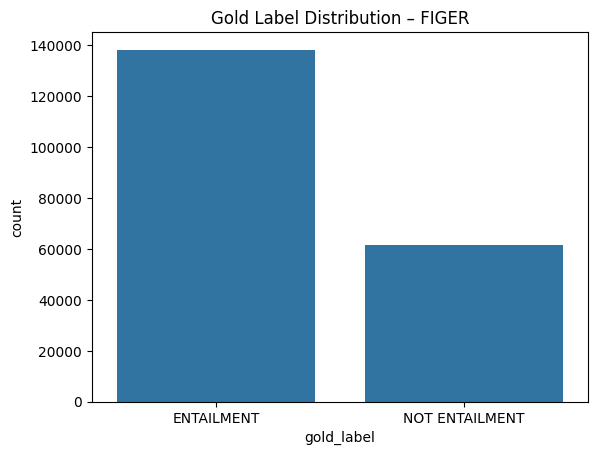

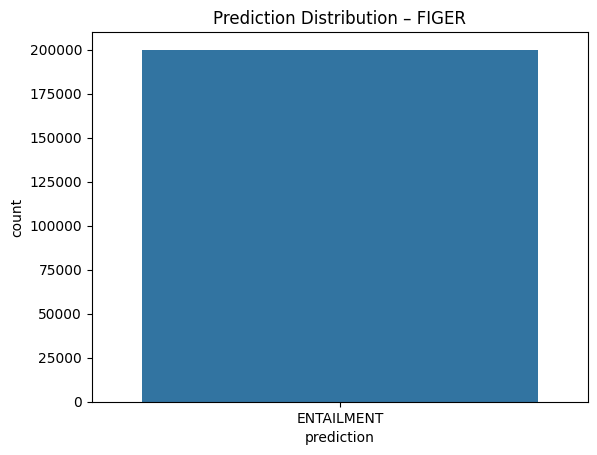

In [3]:
sns.countplot(x='gold_label', data=df)
plt.title('Gold Label Distribution – FIGER')
plt.show()

sns.countplot(x='prediction', data=df)
plt.title('Prediction Distribution – FIGER')
plt.show()

---
## Confusion Matrix

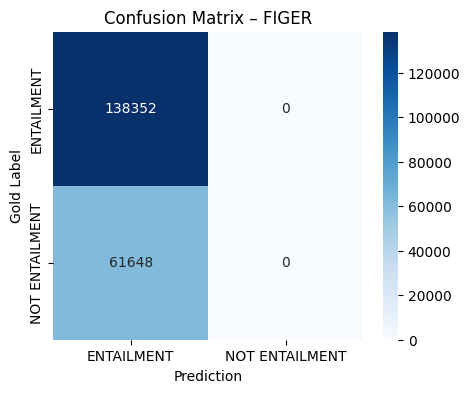

In [4]:
label_order = ["ENTAILMENT", "NOT ENTAILMENT"]

cm = confusion_matrix(df['gold_label'], df['prediction'], labels=label_order)
cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)

plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Gold Label')
plt.xlabel('Prediction')
plt.title('Confusion Matrix – FIGER')
plt.show()

---
## Misclassification and Ambiguity Cases

In [5]:
fp = df[(df['gold_label']=='NOT ENTAILMENT') & (df['prediction']=='ENTAILMENT')]
print(f"Number of FP: {len(fp)}")
fp.head(5)

fn = df[(df['gold_label']=='ENTAILMENT') & (df['prediction']=='NOT ENTAILMENT')]
print(f"Number of FN: {len(fn)}")
fn.head(5)

Number of FP: 61648
Number of FN: 0


,premise,hypothesis,gold_label,prediction


---
## Robustness Test

We perform two complementary masking tests, such as:

1. Entity-Type-Masking: mask only certain entity types in hypothesis
2. Span/Clause Masking: mask full noun or verb phrases to test phrase-level roboustness

In [6]:
nlp = spacy.load("en_core_web_sm", disable=["tagger", "lemmatizer"])

def mask_entities(text, entity_type="PERSON"):
    doc = nlp(text)
    masked_tokens = []
    for token in doc:
        if any(ent.label_ == entity_type for ent in doc.ents if token.idx >= ent.start_char and token.idx < ent.end_char):
            masked_tokens.append('[MASK]')
        else:
            masked_tokens.append(token.text)
    return ' '.join(masked_tokens)

def mask_phrases(text):
    doc = nlp(text)
    masked_tokens = []
    for chunk in doc.noun_chunks:
        for token in chunk:
            masked_tokens.append('[MASK]')
    masked_set = set(token.text for chunk in doc.noun_chunks for token in chunk)
    for token in doc:
        if token.text not in masked_set:
            masked_tokens.append(token.text)
    return ' '.join(masked_tokens)

df['hyp_mask_person'] = [mask_entities(hyp, "PERSON") for hyp in tqdm(df['hypothesis'], desc="Mask Person")]
df['hyp_mask_span']   = [mask_phrases(hyp) for hyp in tqdm(df['hypothesis'], desc="Mask Span")]

df.to_csv("figer_masked.csv", index=False)

Mask Span: 100%|██████████| 200000/200000 [15:45<00:00, 211.52it/s]


---
## Load fine-tuned Model

In [7]:
model_path = r"C:\Users\Laura\Desktop\Uni\5. Semester (WS25-26)\Formale Semantik\Projekt\Analysis\Figer Experiments\figer_predictions__none__premise_sep_hypothesis"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=False)

print("Loading model...")
model = AutoModelForSequenceClassification.from_pretrained(model_path)

print("Setting eval mode...")
model.eval()

print("Done!")

Loading tokenizer...
Loading model...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Setting eval mode...
Done!


---
## Run Masked Inputs on fine-tuned Model

In [9]:
def predict_batch(premises, hypotheses, batch_size=32):
    preds = []
    for i in range(0, len(premises), batch_size):
        batch_p = premises[i:i+batch_size]
        batch_h = hypotheses[i:i+batch_size]
        inputs = tokenizer(batch_p, batch_h, padding=True, truncation=True, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            batch_preds = torch.argmax(logits, dim=1).tolist()
            preds.extend(batch_preds)
    return preds

# -- Predictions on Masked Inputs
pred_mask_person = predict_batch(df['premise'].tolist(), df['hyp_mask_person'].tolist())
pred_mask_span   = predict_batch(df['premise'].tolist(), df['hyp_mask_span'].tolist())

df['pred_mask_person'] = pred_mask_person
df['pred_mask_span']   = pred_mask_span

---
## Label Mapping

In [10]:
label_map = {
    0: "NOT ENTAILMENT",
    1: "ENTAILMENT"
}

df['pred_mask_person_label'] = df['pred_mask_person'].map(label_map)
df['pred_mask_span_label'] = df['pred_mask_span'].map(label_map)

---
## Robustness Test and Error Analysis on Masked Results

In [12]:
# -- Robustness Test

df['change_person'] = df['prediction'] != df['pred_mask_person_label']
df['change_span'] = df['prediction'] != df['pred_mask_span_label']

robustness_person = 1 - df['change_person'].mean()
robustness_span = 1 - df['change_span'].mean()

print(f"Robustness (Person Masking): {robustness_person:.2%}")
print(f"Robustness (Span Masking): {robustness_span:.2%}")

# -- Error Analysis

# False Positives (FP)
fp_person = df[
    (df['gold_label'] == 'NOT ENTAILMENT') &
    (df['pred_mask_person_label'] == 'ENTAILMENT')
]

fp_span = df[
    (df['gold_label'] == 'NOT ENTAILMENT') &
    (df['pred_mask_span_label'] == 'ENTAILMENT')
]

# False Negatives (FN)
fn_person = df[
    (df['gold_label'] == 'ENTAILMENT') &
    (df['pred_mask_person_label'] == 'NOT ENTAILMENT')
]

fn_span = df[
    (df['gold_label'] == 'ENTAILMENT') &
    (df['pred_mask_span_label'] == 'NOT ENTAILMENT')
]

print("\nError Analysis")
print("FP Person:", len(fp_person))
print("FN Person:", len(fn_person))
print("FP Span:", len(fp_span))
print("FN Span:", len(fn_span))

Robustness (Person Masking): 0.00%
Robustness (Span Masking): 0.00%

Error Analysis
FP Person: 0
FN Person: 138352
FP Span: 0
FN Span: 138352


---
## Interpretation

On our original FIGER testset, the model already showed a strong bias towards predicting "ENTAILMENT", resulting in many false positives but no false negatives.

After applying the person and span masking, the robustness goes down to 0%, meaning that almost every prediction changed after the masking.

The error analysis shows that all masked "ENTAILMENT" examples are now misclassified as "NOT ENTAILEMNT".

This indicates that the model heavily relies on presence of specific entities and phrases in the hypothesis to predict "ENTAILMENT". Masking removes that critical information, therefore the model fails to detect positive entailment completly.

In short, the model is highly sensitive to the input for positive examples, while negative examples remain stable.